# 🎬 Netflix Movies & TV Shows — Exploratory Data Analysis & Insights Report

### Contents
1. [Load & Inspect the Data](#step-1)
2. [Clean the Data](#step-2)
3. [Exploratory Data Analysis (5 questions)](#step-3)
4. [Visualizations (7 charts)](#step-4)
5. [Insights Report](#step-5)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

RED, DARK, GREY, LIGHT = "#E50914", "#221F1F", "#B3B3B3", "#F5F5F1"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_PATH = "data/netflix_titles.csv"
IMG_DIR = "images"

<a id="step-2"></a>
---
## Step 1 — Load & Inspect the Data

In [78]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()          # keep the untouched original for before/after comparison

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 8807 rows x 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# Missing values (count and percentage)
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [6]:
# Duplicates: full-row duplicates and duplicate IDs / title+type+year combinations
print("Fully duplicated rows        :", df.duplicated().sum())
print("Duplicated show_id           :", df["show_id"].duplicated().sum())
print("Duplicated title+type+year   :", df.duplicated(subset=["title", "type", "release_year"]).sum())

Fully duplicated rows        : 0
Duplicated show_id           : 0
Duplicated title+type+year   : 0


In [7]:
# Data-quality probe: are the categorical columns internally consistent?
print("Unique values in `rating`:")
print(df["rating"].value_counts(dropna=False).to_string())

Unique values in `rating`:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1


> ⚠️ **Data-quality issue found:** three values in `rating` are actually runtimes (`74 min`, `84 min`, `66 min`), and the `duration` column is empty for the same rows. The values were shifted into the wrong column. This is fixed in Step 2.

In [8]:
# Inspect the misplaced rows
df[df["rating"].astype(str).str.contains("min", na=False)][["title", "director", "rating", "duration"]]

,title,director,rating,duration
5541,Louis C.K. 2017,Louis C.K.,74 min,NaN
5794,Louis C.K.: Hilarious,Louis C.K.,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,Louis C.K.,66 min,NaN


### 📝 Dataset Summary (5 lines)
1. The dataset contains **8,807 titles × 12 columns**: 6,131 Movies (69.6%) and 2,676 TV Shows (30.4%), each with title, cast, director, country, genres, rating, duration and a description.
2. Titles were **released between 1925 and 2021** (median 2017) and **added to Netflix between 2008 and 2021**.
3. Missing data is concentrated in **`director` (29.8%)**, **`country` (9.4%)** and **`cast` (9.4%)**; `date_added`, `rating` and `duration` have only 10, 4 and 3 gaps.
4. There are **no duplicate rows** and every `show_id` is unique, but **3 rows have runtime values misplaced into `rating`**.
5. Several columns hold **multiple values in one cell** (`cast`, `country`, `listed_in`) and `date_added` / `duration` are stored as text, so they need restructuring before analysis.

<a id="step-2"></a>
---
## Step 2 — Clean the Data
Every cleaning decision is documented below with the **reason**. A `cleaning_log` table at the end of this section summarises them all.

In [9]:
cleaning_log = []   # one dict per decision
def log(step, column, action, reason, rows):
    cleaning_log.append({"Step": step, "Column": column, "Action": action, "Reason": reason, "Rows affected": rows})

df = df_raw.copy()

### 2.1 Strip whitespace from text columns
**Why:** stray spaces cause the same value (e.g. `"TV-MA"` vs `"TV-MA "`) to be counted as two categories.

In [10]:
text_cols = df.select_dtypes(include=["object", "string"]).columns
for c in text_cols:
    df[c] = df[c].str.strip()
log("2.1", "all text columns", "Stripped leading/trailing whitespace", "Prevents duplicate categories caused by stray spaces", len(df))

### 2.2 Fix misaligned `rating` / `duration` values
**Why:** in 3 rows the runtime was entered in `rating`. Moving it to `duration` recovers real data instead of discarding it; `rating` for these rows becomes missing (handled in 2.3).

In [11]:
shifted = df["rating"].astype(str).str.contains("min", na=False)
n_shifted = int(shifted.sum())
df.loc[shifted, "duration"] = df.loc[shifted, "rating"]
df.loc[shifted, "rating"] = np.nan
log("2.2", "rating, duration", "Moved runtime from `rating` to `duration`", "Values were shifted into the wrong column", n_shifted)
print(f"Fixed {n_shifted} misaligned rows")

Fixed 3 misaligned rows


### 2.3 Handle missing values
| Column | Missing | Decision | Reason |
|---|---|---|---|
| `date_added` | 10 (0.1%) | **Drop rows** | Needed for every time-based analysis and impossible to infer reliably; loss is negligible |
| `director` | 29.8% | **Fill with `"Unknown"`** | Too many gaps to drop; the rest of each row is still valuable |
| `cast` | 9.4% | **Fill with `"Unknown"`** | Same as above |
| `country` | 9.4% | **Fill with `"Unknown"`** | Keeps the row for type/genre/rating analysis; `Unknown` is excluded from country rankings |
| `rating` | 7 (after 2.2) | **Fill with `"Unknown"`** | Categorical field; imputing a real rating would fabricate data |
| `duration` | 0 (after 2.2) | Nothing needed | The 3 gaps were the misaligned rows |

In [12]:
before = len(df)
df = df.dropna(subset=["date_added"]).copy()
log("2.3", "date_added", "Dropped rows with missing value", "Required for time analysis; only 0.1% of rows", before - len(df))

for col in ["director", "cast", "country", "rating"]:
    n = int(df[col].isna().sum())
    df[col] = df[col].fillna("Unknown")
    log("2.3", col, "Filled missing with 'Unknown'", "Retain the row; do not fabricate values", n)

print(f"Rows dropped: {before - len(df)}  |  Remaining rows: {len(df):,}")
print("Remaining missing values:", int(df.isna().sum().sum()))

Rows dropped: 10  |  Remaining rows: 8,797
Remaining missing values: 0


### 2.4 Fix data types
**Why:** correct types unlock date arithmetic, numeric statistics and lower memory usage.
- `date_added` (text) → **datetime**
- `type`, `rating` → **category**
- `duration` (`"90 min"`, `"2 Seasons"`) → split into numeric **`duration_value`** plus **`duration_unit`**, then into **`movie_minutes`** and **`tv_seasons`**

In [13]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed")
log("2.4", "date_added", "Converted text to datetime", "Enables year/month extraction and date maths", len(df))

df["duration_value"] = df["duration"].str.extract(r"(\d+)")[0].astype(float)
df["duration_unit"]  = df["duration"].str.extract(r"([A-Za-z]+)")[0]
df["movie_minutes"]  = df["duration_value"].where(df["type"] == "Movie")
df["tv_seasons"]     = df["duration_value"].where(df["type"] == "TV Show")
log("2.4", "duration", "Split into numeric movie_minutes / tv_seasons", "Text values cannot be aggregated", len(df))

df["type"]   = df["type"].astype("category")
df["rating"] = df["rating"].astype("category")
log("2.4", "type, rating", "Converted to category dtype", "Low-cardinality fields; saves memory", len(df))

### 2.5 Remove irrelevant columns
- **`show_id`** — an arbitrary row identifier (already verified unique in Step 1), carries no analytical value.
- **`description`** — free text; this project does not use NLP, so it is dropped to keep the table lean.
- **`duration`** (raw text) and **`duration_value` / `duration_unit`** — fully replaced by `movie_minutes` and `tv_seasons`.

In [14]:
df = df.drop(columns=["show_id", "description", "duration", "duration_value", "duration_unit"])
log("2.5", "show_id, description, duration (+ helper columns)", "Dropped columns", "Identifier / unused free text / replaced by numeric columns", 5)

### 2.6 Feature engineering
New columns that make the analysis possible (documented so the work is reproducible):
- `year_added`, `month_added` — from `date_added`
- `primary_country` — first country listed (for one-country-per-title comparisons)
- `audience` — maps maturity ratings to five audience groups:
  **Kids** (G, TV-Y, TV-Y7, TV-Y7-FV, TV-G) · **Family** (PG, TV-PG) · **Teens** (PG-13, TV-14) · **Adults** (R, NC-17, TV-MA) · **Unrated** (NR, UR, Unknown)
- `years_to_netflix` — `year_added − release_year`, i.e. how old a title was when it landed on Netflix

In [15]:
df["year_added"]  = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["primary_country"] = df["country"].str.split(",").str[0].str.strip()

audience_map = {
    "G": "Kids", "TV-Y": "Kids", "TV-Y7": "Kids", "TV-Y7-FV": "Kids", "TV-G": "Kids",
    "PG": "Family", "TV-PG": "Family",
    "PG-13": "Teens", "TV-14": "Teens",
    "R": "Adults", "NC-17": "Adults", "TV-MA": "Adults",
    "NR": "Unrated", "UR": "Unrated", "Unknown": "Unrated",
}
df["audience"] = df["rating"].astype(str).map(audience_map)
df["years_to_netflix"] = df["year_added"] - df["release_year"]

log("2.6", "year_added, month_added, primary_country, audience, years_to_netflix", "Created new features", "Support time, geographic, audience and freshness analysis", len(df))
print("Unmapped ratings:", df["audience"].isna().sum())

Unmapped ratings: 0


### 2.7 Validation — before vs after

In [16]:
df = df.reset_index(drop=True)
core_cols = [c for c in df.columns if c not in ("movie_minutes", "tv_seasons")]   # these two are NaN by design (movie vs TV)
validation = pd.DataFrame({
    "Before": [df_raw.shape[0], df_raw.shape[1], int(df_raw.isna().sum().sum()), int(df_raw.duplicated().sum())],
    "After":  [df.shape[0], df.shape[1], int(df[core_cols].isna().sum().sum()), int(df.duplicated().sum())],
}, index=["Rows", "Columns", "Missing values (excl. movie_minutes / tv_seasons, NaN by design)", "Duplicate rows"])
display(validation)
df.dtypes.to_frame("dtype").T

,Before,After
Rows,8807,8797
Columns,12,16
"Missing values (excl. movie_minutes / tv_seasons, NaN by design)",4307,0
Duplicate rows,0,1


,type,title,director,cast,country,date_added,release_year,rating,listed_in,movie_minutes,tv_seasons,year_added,month_added,primary_country,audience,years_to_netflix
dtype,category,object,object,object,object,datetime64[ns],int64,category,object,float64,float64,int32,int32,object,object,int64


### 2.8 Cleaning log — every decision in one table

In [17]:
pd.DataFrame(cleaning_log)

,Step,Column,Action,Reason,Rows affected
0,2.1,all text columns,Stripped leading/trailing whitespace,Prevents duplicate categories caused by stray ...,8807
1,2.2,"rating, duration",Moved runtime from `rating` to `duration`,Values were shifted into the wrong column,3
2,2.3,date_added,Dropped rows with missing value,Required for time analysis; only 0.1% of rows,10
3,2.3,director,Filled missing with 'Unknown',Retain the row; do not fabricate values,2624
4,2.3,cast,Filled missing with 'Unknown',Retain the row; do not fabricate values,825
5,2.3,country,Filled missing with 'Unknown',Retain the row; do not fabricate values,830
6,2.3,rating,Filled missing with 'Unknown',Retain the row; do not fabricate values,7
7,2.4,date_added,Converted text to datetime,Enables year/month extraction and date maths,8797
8,2.4,duration,Split into numeric movie_minutes / tv_seasons,Text values cannot be aggregated,8797
9,2.4,"type, rating",Converted to category dtype,Low-cardinality fields; saves memory,8797


In [18]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,listed_in,movie_minutes,tv_seasons,year_added,month_added,primary_country,audience,years_to_netflix
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,Documentaries,90.00,NaN,2021,9,United States,Teens,1
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",NaN,2.00,2021,9,South Africa,Adults,0
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",NaN,1.00,2021,9,Unknown,Adults,0
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV",NaN,1.00,2021,9,Unknown,Adults,0
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",NaN,2.00,2021,9,India,Adults,0


<a id="step-3"></a>
---
## Step 3 — Exploratory Data Analysis
Five business questions, each answered with Pandas (`value_counts`, `groupby`, `describe`, `crosstab`) and code output.

### Q1. What is the split between Movies and TV Shows in the catalogue?

In [19]:
q1 = df["type"].value_counts().to_frame("titles")
q1["share_%"] = (df["type"].value_counts(normalize=True) * 100).round(1)
q1

,titles,share_%
type,,
Movie,6131,69.70
TV Show,2666,30.30


**Finding:** roughly seven in ten titles are Movies, so the catalogue leans heavily towards films.

### Q2. Which countries contribute the most content?
Titles list every co-producing country, so `country` is split and exploded: a US–UK co-production counts for both. `Unknown` is excluded.

In [36]:
country = (df.assign(country=df["country"].str.split(","))
                  .explode("country"))
country["country"] = country["country"].str.strip()
country_long = country[country["country"] != "Unknown"]

q2 = country["country"].value_counts().head(10).to_frame("titles")
q2["share_of_all_titles_%"] = (q2["titles"] / len(df) * 100).round(1)
q2

,titles,share_of_all_titles_%
country,,
United States,3684,41.90
India,1046,11.90
Unknown,830,9.40
United Kingdom,805,9.20
Canada,445,5.10
France,393,4.50
Japan,317,3.60
Spain,232,2.60
South Korea,231,2.60


In [37]:
# Content mix of the top 5 countries: Movie vs TV Show
top5 = q2.index[:5]
mix = (country[country["country"].isin(top5)]
       .groupby(["country", "type"], observed=True).size().unstack().loc[top5])
mix["tv_share_%"] = (mix["TV Show"] / (mix["Movie"] + mix["TV Show"]) * 100).round(1)
mix

type,Movie,TV Show,tv_share_%
country,,,
United States,2752,932,25.30
India,962,84,8.00
Unknown,440,390,47.00
United Kingdom,534,271,33.70
Canada,319,126,28.30


### Q3. What are the most common genres for Movies and for TV Shows?
`listed_in` holds several genres per title, so it is split and exploded before grouping.

In [38]:
genre = df.assign(genre=df["listed_in"].str.split(",")).explode("genre")
genre["genre"] = genre["genre"].str.strip()

q3 = (genre.groupby(["type", "genre"], observed=True).size()
        .rename("titles").reset_index()
        .sort_values(["type", "titles"], ascending=[True, False])
        .groupby("type", observed=True).head(6))
q3

,type,genre,titles
11,Movie,International Movies,2752
7,Movie,Dramas,2427
4,Movie,Comedies,1674
6,Movie,Documentaries,869
0,Movie,Action & Adventure,859
10,Movie,Independent Movies,756
25,TV Show,International TV Shows,1350
35,TV Show,TV Dramas,762
34,TV Show,TV Comedies,574
23,TV Show,Crime TV Shows,469


**Finding:** International content, Dramas and Comedies dominate movies; TV is led by International TV Shows, TV Dramas and TV Comedies. Documentaries are a top-5 movie genre.

### Q4. How long are Movies, and how many seasons do TV Shows run?

In [44]:
print("MOVIE RUNTIME (minutes)")
display(df["movie_minutes"].describe().to_frame("movie_minutes").T)
long_movies = (df["movie_minutes"] > 150).sum()
print(f"Movies longer than 150 minutes: {long_movies}")

print("\nTV SHOWS — share by number of seasons (%)")
(df["tv_seasons"].value_counts(normalize=True).sort_index().mul(100).round(1)
   .rename("share_%").to_frame().head(6))

MOVIE RUNTIME (minutes)


,count,mean,std,min,25%,50%,75%,max
movie_minutes,"6,131.00",99.56,28.29,3.00,87.00,98.00,114.00,312.00


Movies longer than 150 minutes: 245

TV SHOWS — share by number of seasons (%)


,share_%
tv_seasons,
1.00,67.30
2.00,15.80
3.00,7.40
4.00,3.50
5.00,2.40
6.00,1.20


**Finding:** the typical movie runs about 98 minutes, and about two-thirds of TV shows have just one season.

### Q5. Which audiences does the catalogue target, and do Movies and TV Shows differ?

In [26]:
print("Share of each type by maturity rating (%):")
display((pd.crosstab(df["rating"], df["type"], normalize="columns") * 100).round(1)
        .sort_values("Movie", ascending=False))

print("Share of each type by audience group (%):")
q5 = (pd.crosstab(df["audience"], df["type"], normalize="columns") * 100).round(1)
q5.loc[["Kids", "Family", "Teens", "Adults", "Unrated"]]

Share of each type by maturity rating (%):


type,Movie,TV Show
rating,,
TV-MA,33.60,42.90
TV-14,23.30,27.40
R,13.00,0.10
TV-PG,8.80,12.00
PG-13,8.00,0.00
PG,4.70,0.00
TV-Y7,2.30,7.30
TV-Y,2.10,6.60
TV-G,2.10,3.50


Share of each type by audience group (%):


type,Movie,TV Show
audience,,
Kids,7.20,17.40
Family,13.50,12.00
Teens,31.30,27.40
Adults,46.70,42.90
Unrated,1.40,0.20


**Finding:** Adult-rated content (TV-MA, R) is the largest single audience group for both types, and TV Shows carry a much larger share of Kids content than Movies.

<a id="step-4"></a>
---
## Step 4 — Visualizations (7 charts)
Every chart has a title, labelled axes and a readable layout, and is saved to `images/` for the README.

In [27]:
import os
os.makedirs(IMG_DIR, exist_ok=True)
TYPE_COLORS = {"Movie": RED, "TV Show": DARK}

def save(fig, name):
    fig.savefig(f"{IMG_DIR}/{name}.png", dpi=150, bbox_inches="tight", facecolor="white")

### Chart 1 — Pie (donut) chart: Movies vs TV Shows

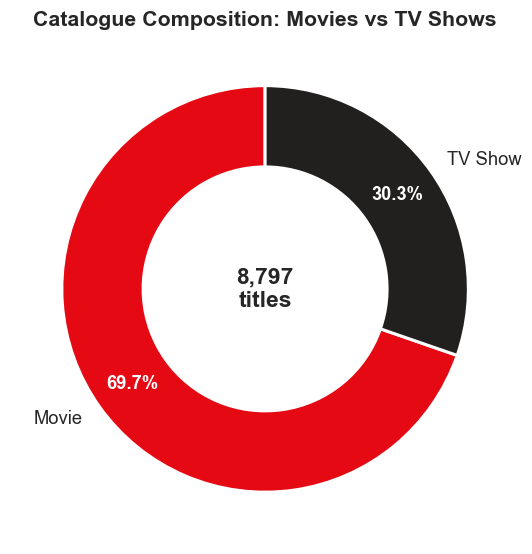

In [52]:
fig, x = plt.subplots(figsize=(6, 6))
counts = df["type"].value_counts()
wedges, texts, autotexts = x.pie(
    counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
    colors=[TYPE_COLORS[t] for t in counts.index], pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
    textprops={"fontsize": 12})
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold")
x.text(0, 0, f"{len(df):,}\ntitles", ha="center", va="center", fontsize=15, fontweight="bold")
x.set_title("Catalogue Composition: Movies vs TV Shows")
save(fig, "01_pie_type_split"); plt.show()

### Chart 2 — Bar chart: Top 10 content-producing countries

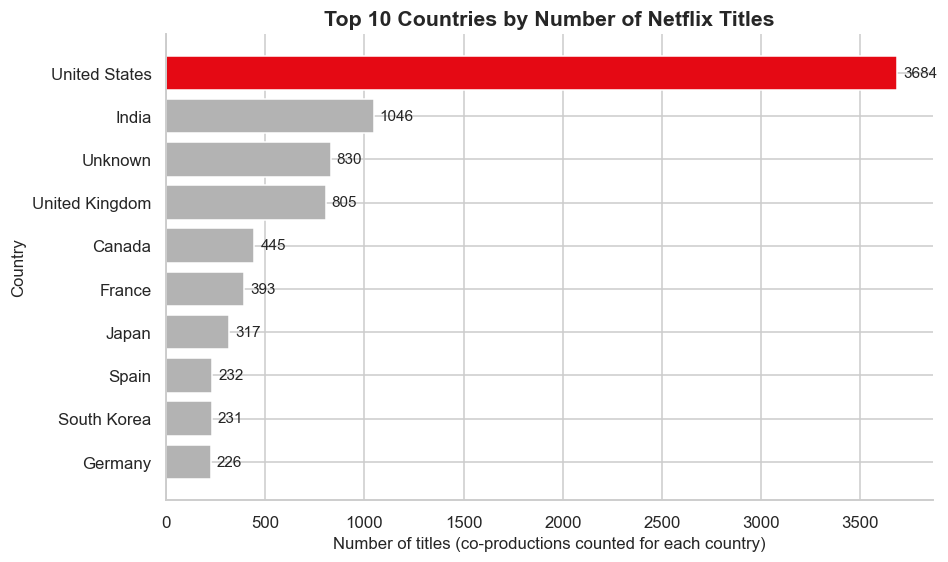

In [58]:
top10 = country["country"].value_counts().head(10).sort_values()
fig, x = plt.subplots(figsize=(9, 5.5))
bars = x.barh(top10.index, top10.values, color=[RED if c == "United States" else GREY for c in top10.index])
x.bar_label(bars, padding=4, fontsize=10)
x.set_title("Top 10 Countries by Number of Netflix Titles")
x.set_xlabel("Number of titles (co-productions counted for each country)")
x.set_ylabel("Country")
save(fig, "02_bar_top_countries"); plt.show()

### Chart 3 — Line chart: Titles added per year, by type

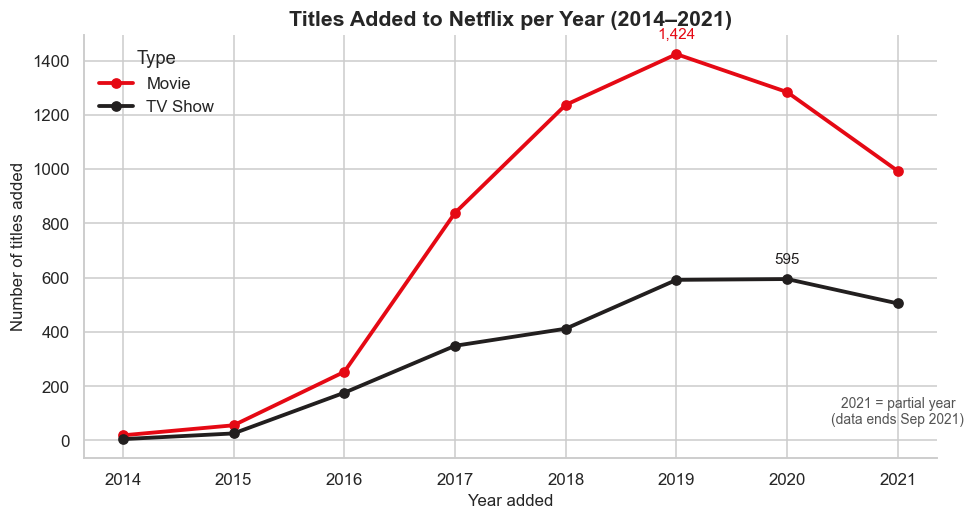

type,Movie,TV Show
year_added,,
2014,19,5
2015,56,26
2016,253,176
2017,839,349
2018,1237,412
2019,1424,592
2020,1284,595
2021,993,505


In [70]:
added = (df[df["year_added"] >= 2014]
         .groupby(["year_added", "type"], observed=True).size().unstack())
fig, x = plt.subplots(figsize=(10, 5))
for t in ["Movie", "TV Show"]:
    x.plot(added.index, added[t], marker="o", linewidth=2.5, color=TYPE_COLORS[t], label=t)
    x.annotate(f"{added[t].max():,}", (added[t].idxmax(), added[t].max()),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10, color=TYPE_COLORS[t])
x.text(2021, 60, "2021 = partial year\n(data ends Sep 2021)", ha="center", fontsize=9, color="#555")
x.set_title("Titles Added to Netflix per Year (2014–2021)")
x.set_xlabel("Year added"); x.set_ylabel("Number of titles added")
x.legend(title="Type", frameon=False)
save(fig, "03_line_titles_added_per_year"); plt.show()
added

### Chart 4 — Histogram: Movie runtime distribution

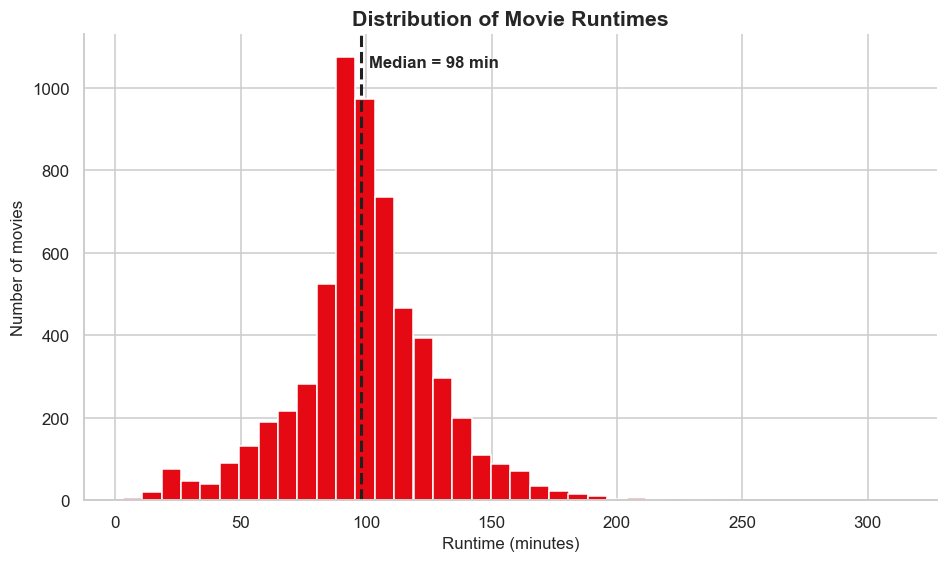

In [74]:
mins = df["movie_minutes"].dropna()
fig, x = plt.subplots(figsize=(10, 5.5))
x.hist(mins, bins=40, color=RED, edgecolor="white")
x.axvline(mins.median(), color=DARK, linestyle="--", linewidth=2)
x.text(mins.median() + 3, x.get_ylim()[1] * 0.93, f"Median = {mins.median():.0f} min", fontsize=11, fontweight="bold")
x.set_title("Distribution of Movie Runtimes")
x.set_xlabel("Runtime (minutes)"); x.set_ylabel("Number of movies")
save(fig, "04_histogram_movie_runtime"); plt.show()

### Chart 5 — Scatter plot: Release year vs year added to Netflix

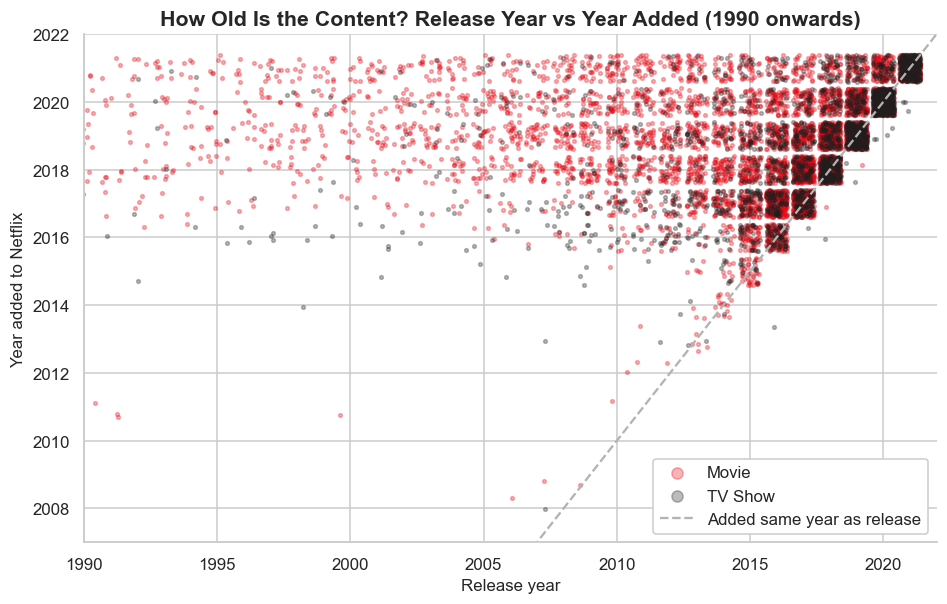

In [32]:
rng = np.random.default_rng(42)
sc = df[df["release_year"] >= 1990].copy()
sc["x"] = sc["release_year"] + rng.uniform(-0.4, 0.4, len(sc))      # jitter so points don't stack
sc["y"] = sc["year_added"]     + rng.uniform(-0.4, 0.4, len(sc))

fig, ax = plt.subplots(figsize=(10, 6))
for t, g in sc.groupby("type", observed=True):
    ax.scatter(g["x"], g["y"], s=6, alpha=0.3, color=TYPE_COLORS[t], label=t)
lims = [1990, 2022]
ax.plot(lims, lims, color=GREY, linestyle="--", linewidth=1.5, label="Added same year as release")
ax.set_xlim(lims); ax.set_ylim(2007, 2022)
ax.set_title("How Old Is the Content? Release Year vs Year Added (1990 onwards)")
ax.set_xlabel("Release year"); ax.set_ylabel("Year added to Netflix")
ax.legend(frameon=True, facecolor="white", framealpha=1, markerscale=3, loc="lower right")
save(fig, "05_scatter_release_vs_added"); plt.show()

### Chart 6 — Heatmap: When does Netflix add content? (month × year)

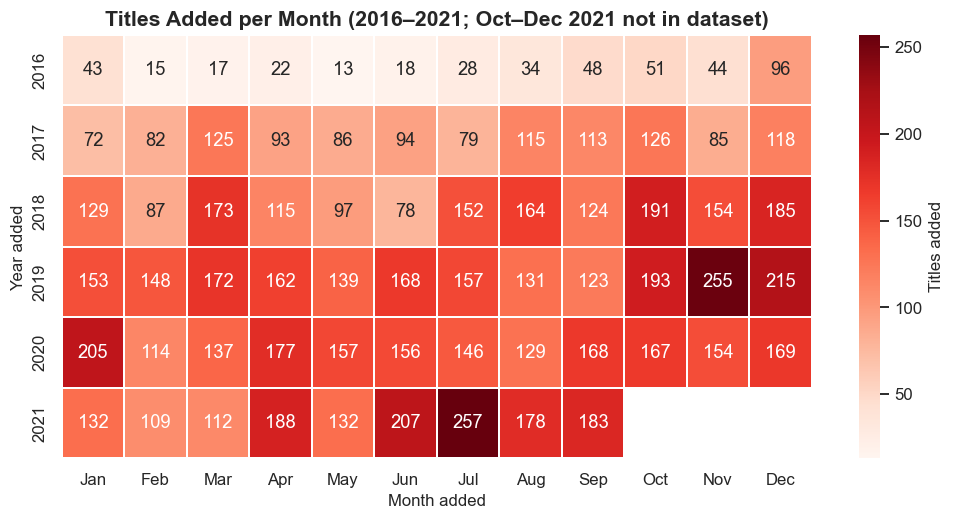

In [33]:
heat = (df[df["year_added"] >= 2016]
        .pivot_table(index="year_added", columns="month_added", values="title", aggfunc="count"))
heat.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Reds", linewidths=1, linecolor="white",
            cbar_kws={"label": "Titles added"}, ax=ax)
ax.set_title("Titles Added per Month (2016–2021; Oct–Dec 2021 not in dataset)")
ax.grid(False)
ax.set_xlabel("Month added"); ax.set_ylabel("Year added")
save(fig, "06_heatmap_month_year"); plt.show()

### Chart 7 — Stacked bar chart: Audience mix by content type

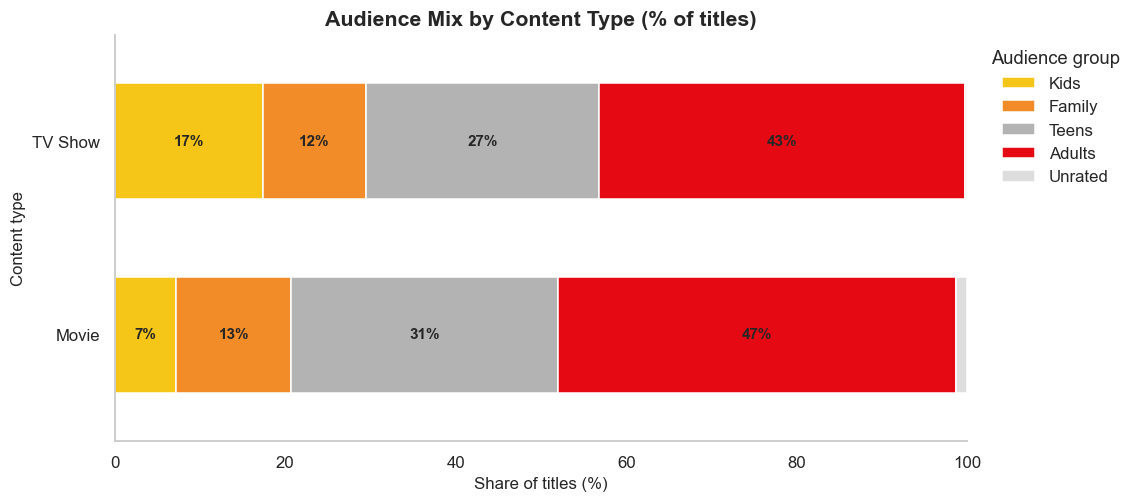

In [34]:
order = ["Kids", "Family", "Teens", "Adults", "Unrated"]
palette = ["#F5C518", "#F28C28", "#B3B3B3", RED, "#DDDDDD"]
aud = (pd.crosstab(df["type"], df["audience"], normalize="index") * 100)[order]
fig, ax = plt.subplots(figsize=(10, 4.8))
aud.plot(kind="barh", stacked=True, color=palette, edgecolor="white", ax=ax, width=0.6)
for container in ax.containers:
    labels = [f"{v.get_width():.0f}%" if v.get_width() >= 4 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=10, fontweight="bold")
ax.set_title("Audience Mix by Content Type (% of titles)")
ax.set_xlabel("Share of titles (%)"); ax.set_ylabel("Content type")
ax.set_xlim(0, 100)
ax.grid(False)
ax.legend(title="Audience group", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
save(fig, "07_stacked_bar_audience_by_type"); plt.show()

<a id="step-5"></a>
---
## Step 5 — Insights Report
The evidence cell below recomputes every number quoted in the insights, so each claim can be traced back to the data.

In [35]:
total = len(df)
tv_share = (df["type"] == "TV Show").mean()
by_year = df.groupby("year_added").size()
peak_year = by_year.idxmax()
us_share = df["country"].str.contains("United States").mean()
in_share = df["country"].str.contains("India").mean()
uk_share = df["country"].str.contains("United Kingdom").mean()
adult_share = (df["audience"] == "Adults").mean()
kids_tv  = (df.loc[df["type"] == "TV Show", "audience"] == "Kids").mean()
kids_mv  = (df.loc[df["type"] == "Movie", "audience"] == "Kids").mean()
within2  = (df["years_to_netflix"] <= 2).mean()
recent_tv = (df.loc[df["type"] == "TV Show", "release_year"] >= 2015).mean()
recent_mv = (df.loc[df["type"] == "Movie", "release_year"] >= 2015).mean()
one_season = (df["tv_seasons"].dropna() == 1).mean()
monthly = df[df["year_added"].between(2016, 2020)].groupby("month_added").size()
m2021 = df[df["year_added"] == 2021].groupby("month_added").size()

evidence = {
    "Movies share of catalogue": f"{1 - tv_share:.1%}",
    "TV Shows share of catalogue": f"{tv_share:.1%}",
    "Titles added 2015 -> 2019 (peak)": f"{by_year[2015]:,} -> {by_year[2019]:,}",
    "Peak year for additions": f"{peak_year} ({by_year.max():,} titles)",
    "Titles added in 2020 vs 2019": f"{by_year[2020]:,} vs {by_year[2019]:,} ({by_year[2020]/by_year[2019]-1:+.1%})",
    "2021 monthly run-rate (Jan-Sep) vs 2020 (full year)": f"{m2021.mean():.0f} vs {by_year[2020]/12:.0f} titles/month",
    "Titles with US / India / UK involvement": f"{us_share:.1%} / {in_share:.1%} / {uk_share:.1%}",
    "Adult-rated share of catalogue": f"{adult_share:.1%}",
    "Kids share of TV Shows / Movies": f"{kids_tv:.1%} / {kids_mv:.1%}",
    "Median years from release to Netflix": f"{df['years_to_netflix'].median():.0f}",
    "Added within 2 years of release": f"{within2:.1%}",
    "Released 2015+ (TV Shows / Movies)": f"{recent_tv:.1%} / {recent_mv:.1%}",
    "TV Shows with a single season": f"{one_season:.1%}",
    "Median movie runtime (min)": f"{df['movie_minutes'].median():.0f}",
    "Busiest / quietest month (2016-2020 total)": f"{monthly.idxmax()} ({monthly.max()}) / {monthly.idxmin()} ({monthly.min()})",
}
pd.Series(evidence, name="Value").to_frame()

,Value
Movies share of catalogue,69.7%
TV Shows share of catalogue,30.3%
Titles added 2015 -> 2019 (peak),"82 -> 2,016"
Peak year for additions,"2019 (2,016 titles)"
Titles added in 2020 vs 2019,"1,879 vs 2,016 (-6.8%)"
2021 monthly run-rate (Jan-Sep) vs 2020 (full year),166 vs 157 titles/month
Titles with US / India / UK involvement,41.9% / 11.9% / 9.2%
Adult-rated share of catalogue,45.5%
Kids share of TV Shows / Movies,17.4% / 7.2%
Median years from release to Netflix,1


## 🔎 Five Data-Backed Insights & Recommendations

**1. The catalogue is a movie library first (Chart 1).**
Movies make up **69.7%** of titles versus **30.3%** for TV Shows (Q1, Chart 1). TV Shows are the format that builds subscriber habit and retention, so a 70/30 skew suggests room to **shift acquisition and production budget towards series**, especially in the genres where TV is thin.

**2. Content growth peaked in 2019 and has cooled since (Charts 3 and 6).**
Additions rose from **82 titles in 2015 to 2,016 in 2019**, then fell **6.8% in 2020** (1,879) (Chart 3). 2021 is only a partial year (data ends September); its run-rate of ~166 titles/month is slightly above 2020 (~157) but level with the 2019 peak (~168), so growth has **plateaued rather than rebounded**. The heatmap (Chart 6) also shows a seasonal pattern: across 2016–2020 **December is the busiest month (783 titles) and February the quietest (446)**. Recommendation: **treat raw volume as no longer the growth lever**, focus on quality, schedule tentpole releases around the busy December window, and use February for smaller or niche releases.

**3. Supply is concentrated in the US, with India as the standout second market (Chart 2, Q2).**
The US is involved in **~42%** of titles and India in **~12%**, ahead of the UK (~9%) (Chart 2). India's slate is overwhelmingly movies (92%), while Japan (63% TV) and South Korea (74% TV) are TV-led (Q2). Recommendation: **invest in local-language series in India** to fill the TV gap, and keep expanding Korean, Japanese and UK series, which are already TV-led.

**4. The catalogue skews mature, and Kids TV is the main family offering (Chart 7, Q5).**
**~46%** of all titles are Adult-rated (TV-MA/R), and TV-MA alone is the biggest single rating for both Movies (33.6%) and TV Shows (42.9%) (Q5). Kids content is **17.4% of TV Shows but only 7.2% of Movies** (Chart 7). Recommendation: **family and kids' films are an under-served segment**; adding them would improve appeal for households with children and could reduce churn in family accounts.

**5. Netflix leans on fresh content, and most TV shows never get a second season (Charts 4 and 5, Q4).**
The median title reaches Netflix **1 year after release**, **63%** arrive within 2 years, and **82% of TV Shows were released in 2015 or later** versus 66% of Movies (Chart 5). Two-thirds (**67%**) of TV Shows have only one season, and movies cluster tightly around a **98-minute median** runtime (Chart 4). Recommendation: **the back-catalogue of older classics is thin, so licensing well-loved older titles** is a cost-effective way to add variety, while renewal decisions should look closely at second-season conversion.

### 💡 The Finding That Surprised Me Most
What surprised me most was how sudden Netflix's growth was, and how quickly it levelled off. Additions jumped from just 82 titles in 2015 to 2,016 in 2019, roughly a 25x increase in four years, yet 2020 fell 6.8% and 2021's monthly pace is only level with 2019. I expected a streaming giant's catalogue to keep climbing, but the data suggests Netflix has moved from a "add as much as possible" phase to a more selective one. It also made me realise that catalogue size alone is a weak measure of success, and that viewership data would be the natural next step to explore.